In [1]:
#Import libraries
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
import os
import ar
import utils
import matplotlib.pyplot as plt

In [2]:
#Define pipe and data import
filt = utils.Filter()
rec = utils.Reconstruct()
window = utils.Window()
coef_train = utils.TrainAr()

feature_pipe = Pipeline(steps=[('Filter', filt),
                               ('Reconstruction', rec),
                               ('Windowing', window)])

path = '../Dataset/Treino dataset'
files = sorted(os.listdir(path), key=lambda x: int(x[5:-4]))

In [3]:
#Apply pipeline
file_name = os.path.join(path, files[0])

#Loading the dataset
df = np.transpose(np.asarray(
    pd.read_table(file_name, sep='\t', skiprows=10))[:, :])

t = df[0, :]
df = df[1:, :]

X = feature_pipe.fit_transform(df)

In [36]:
#Evaluation 
##Akaike Information Criterion
orders = np.arange(0,150,1)
aic = np.zeros((len(orders),100))
# x_pred = np.zeros((X.shape[1] - 1, len(orders)))

for j in range(100):
    for i in range(len(orders)):
        model = ar.ar()
        model.fit(X[j,:,0], order=i)
        x_pred = model.predict(X[j,:,0])
        ss_error = np.sum(X[j,i:,0] - x_pred)**2
        n = len(x_pred)
        aic[i,j] = n*np.log(ss_error/n) + 2*i


c:\Users\Guilherme Zerwes\OneDrive - Universidade Federal do Espírito Santo\UFES\Projeto de Graduação\Codigo\ar.py:26: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coefs = np.linalg.lstsq(X_train, Y_train)[0]


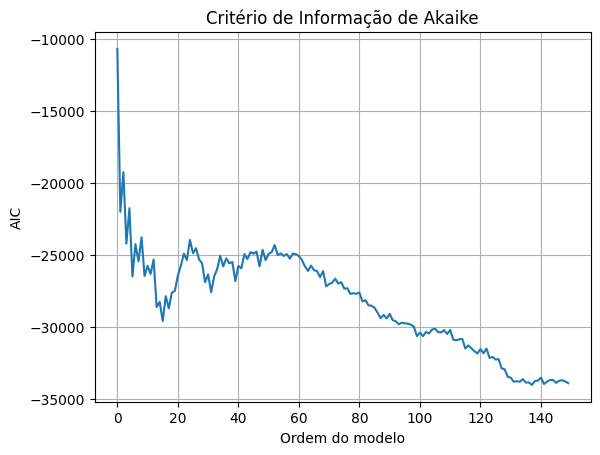

In [49]:
plt.plot(orders,np.mean(aic,axis=1))
# plt.xlim([0,20])
plt.grid()
plt.title("Critério de Informação de Akaike")
plt.xlabel("Ordem do modelo")
plt.ylabel("AIC")
plt.show()

In [59]:
#AR model training
nr = 15 #number of regressive coeficients (ie. lag number)

aux1 = int(0.8*X.shape[0])
train,test = X[:aux1, :,:], X[aux1:, :,:]

coeficients = np.zeros((train.shape[0], X.shape[2], nr))
x_hat = np.zeros((X.shape[1] - nr,30))
# scores = np.zeros((y_train.shape[1]))

# for i in range(X.shape[0]):
#     print(i)
for j in range(X.shape[2]):
    model = ar.ar()
    model.fit(train[0,:,j], order=nr)
    coeficients[0,j] = model.coefs
# coeficients = np.reshape(coeficients, (X.shape[0], X.shape[2]*nr))

for i in range(X.shape[2]):
    x_hat[:,i] = model.predict(test[0,:,i])


c:\Users\Guilherme Zerwes\OneDrive - Universidade Federal do Espírito Santo\UFES\Projeto de Graduação\Codigo\ar.py:26: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coefs = np.linalg.lstsq(X_train, Y_train)[0]


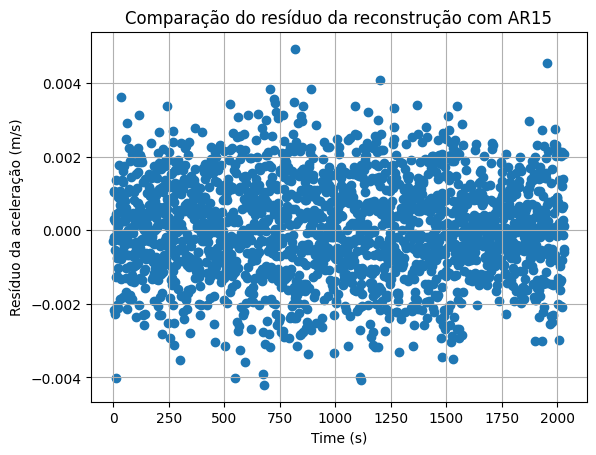

Score R² médio: 0.9992607951454038


In [66]:
#Evaluation
##Residue Scatter plot
res = test[0,nr:,0] - x_hat[:,0]

plt.scatter(np.arange(0,len(res),1),res)
plt.grid()
plt.xlabel('Time (s)')
plt.ylabel('Resíduo da aceleração (m/s)')
plt.title(f'Comparação do resíduo da reconstrução com AR{nr}')
plt.show()

r2_score = 0
for i in range(X.shape[2]):
    res = test[0,nr:,i] - x_hat[:,i]
    r2_score += 1- np.sum((test[0,nr:,i] - x_hat[:,i])**2)/np.sum((test[0,nr:,i] - np.mean(test[0,nr:,i]))**2)
print("Score R² médio:", r2_score/X.shape[2])

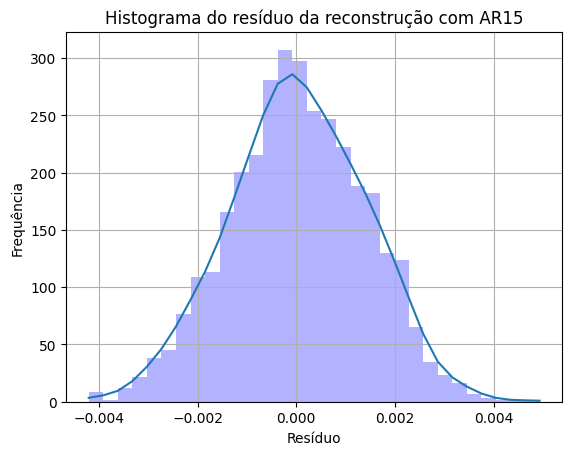

In [ ]:
#Evaluate
##Residue histrogram
from scipy.stats import gaussian_kde

density = gaussian_kde(res)
density.covariance_factor = lambda : .25
density._compute_covariance()

bin_edges = np.histogram_bin_edges(res, bins='auto')

plt.plot(bin_edges, density(bin_edges))
plt.hist(res, bins=bin_edges, alpha=0.3, density=True, color='blue')
plt.grid()
plt.xlabel('Resíduo')
plt.ylabel('Frequência')
plt.title(f'Histograma do resíduo com AR{nr}')
# plt.xlim([-0.04,0.04])
plt.show()

9.814029487047555e-05 -2.1358095046046386e-05


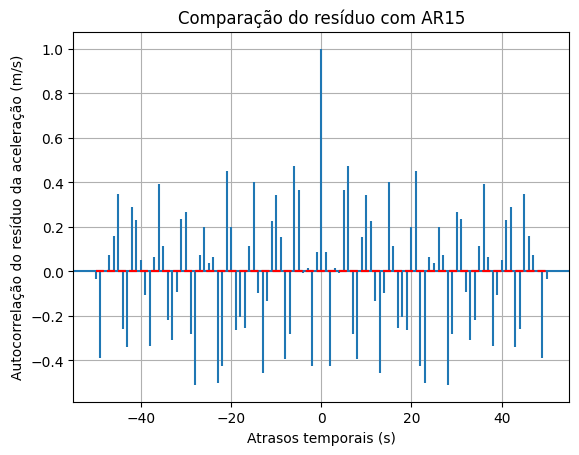

In [64]:
#Evaluation
##Auto-corelation residue plot
#Não sei o que conlcuir disso??w
z95 = 1.96
ci_inf = np.mean(res) - z95*np.std(res)/np.sqrt(len(res))
ci_sup = np.mean(res) + z95*np.std(res)/np.sqrt(len(res))

print(ci_sup, ci_inf)

plt.acorr(res, maxlags=50)
plt.hlines(ci_inf, xmin=-50, xmax=50, linestyles='dashed', colors='red')
plt.hlines(ci_sup, xmin=-50, xmax=50, linestyles='dashed', colors='red')
plt.grid()
plt.xlabel('Atrasos temporais (s)')
plt.ylabel('Autocorrelação do resíduo da aceleração (m/s)')
plt.title(f'Comparação do resíduo com AR{nr}')
plt.show()